In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load Data
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
# a. Define Early Stopping
# monitor: What to watch (Validation Loss is best)
# patience: How many epochs to wait for improvement before killing the process
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

# b. Build Model with Dropout
model = Sequential([
    Dense(30, activation='relu', input_shape=(30,)),
    Dropout(0.5),  # 50% of neurons are randomly "turned off" each epoch
    
    Dense(15, activation='relu'),
    Dropout(0.5),  # Prevents hidden layers from co-depending on specific neurons
    
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=600,  # We set it high, but Early Stopping will stop it early
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)



Epoch 1/600


15/15 [==============================] - 2s 28ms/step - loss: 1.0627 - accuracy: 0.4440 - val_loss: 0.6749 - val_accuracy: 0.4561
Epoch 2/600
15/15 [==============================] - 0s 9ms/step - loss: 0.8045 - accuracy: 0.5341 - val_loss: 0.4988 - val_accuracy: 0.8246
Epoch 3/600
15/15 [==============================] - 0s 8ms/step - loss: 0.6671 - accuracy: 0.6220 - val_loss: 0.4018 - val_accuracy: 0.9211
Epoch 4/600
15/15 [==============================] - 0s 7ms/step - loss: 0.6310 - accuracy: 0.6791 - val_loss: 0.3355 - val_accuracy: 0.9386
Epoch 5/600
15/15 [==============================] - 0s 7ms/step - loss: 0.5064 - accuracy: 0.7451 - val_loss: 0.2827 - val_accuracy: 0.9649
Epoch 6/600
15/15 [==============================] - 0s 7ms/step - loss: 0.4423 - accuracy: 0.7868 - val_loss: 0.2416 - val_accuracy: 0.9737
Epoch 7/600
15/15 [==============================] - 0s 7ms/step - loss: 0.4163 - accuracy: 0.8000 - val_loss: 0.2097 - val_accuracy: 0.9737
Epoch 8/

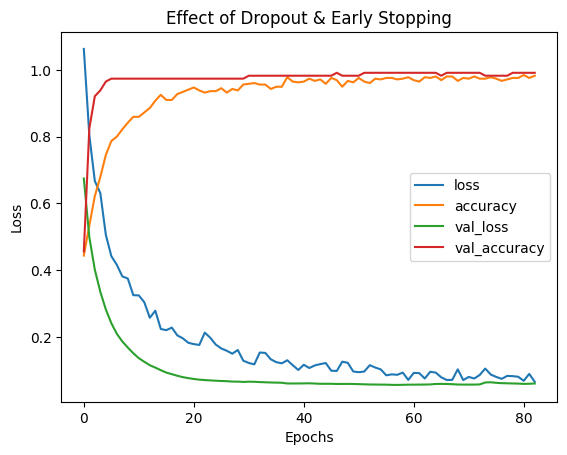

In [3]:
# Plotting the loss to see Early Stopping in action
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()
plt.title('Effect of Dropout & Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()